In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [139]:
distances = pd.read_csv('distance_data.csv')
distances.head()

,x,y,theta,distance
0,180.0,540.0,0.0,205.000000
1,180.0,540.0,5.0,207.781135
2,180.0,540.0,10.0,213.234613
3,180.0,540.0,15.0,219.529041
4,180.0,540.0,20.0,227.771816


array([[<Axes: xlabel='x', ylabel='x'>, <Axes: xlabel='y', ylabel='x'>,
        <Axes: xlabel='theta', ylabel='x'>,
        <Axes: xlabel='distance', ylabel='x'>],
       [<Axes: xlabel='x', ylabel='y'>, <Axes: xlabel='y', ylabel='y'>,
        <Axes: xlabel='theta', ylabel='y'>,
        <Axes: xlabel='distance', ylabel='y'>],
       [<Axes: xlabel='x', ylabel='theta'>,
        <Axes: xlabel='y', ylabel='theta'>,
        <Axes: xlabel='theta', ylabel='theta'>,
        <Axes: xlabel='distance', ylabel='theta'>],
       [<Axes: xlabel='x', ylabel='distance'>,
        <Axes: xlabel='y', ylabel='distance'>,
        <Axes: xlabel='theta', ylabel='distance'>,
        <Axes: xlabel='distance', ylabel='distance'>]], dtype=object)

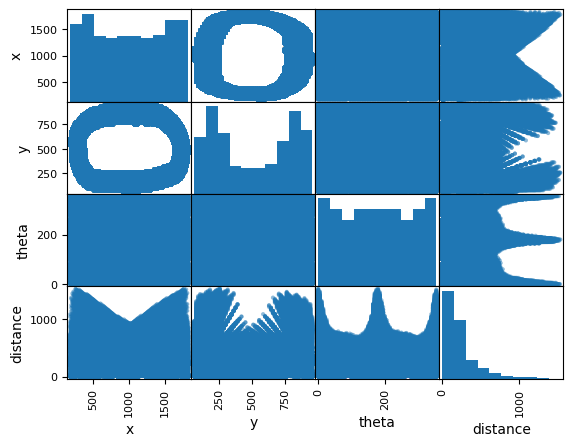

In [140]:
pd.plotting.scatter_matrix(distances)

(array([2.6505e+04, 5.7400e+02, 1.7200e+02, 2.1600e+02, 4.9000e+01,
        4.2000e+01, 4.1000e+01, 4.4000e+01, 2.4000e+01, 9.0000e+00]),
 array([0.00066711, 0.0506004 , 0.10053369, 0.15046698, 0.20040027,
        0.25033356, 0.30026684, 0.35020013, 0.40013342, 0.45006671,
        0.5       ]),
 <BarContainer object of 10 artists>)

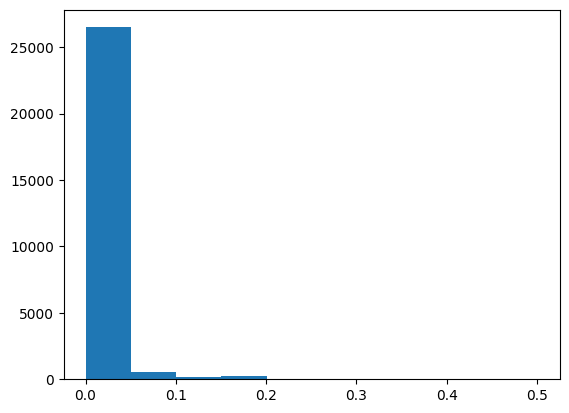

In [106]:
plt.hist(1/distances['distance'])

In [10]:
print(distances['distance'].iloc[0:200].to_string())

0       205.000000
1       213.234613
2       227.771816
3       249.561616
4       740.314123
5       618.934568
6       527.773626
7       411.885907
8       258.940148
9        11.180340
10        5.385165
11        3.605551
12        2.828427
13        2.828427
14        2.236068
15        2.236068
16        2.000000
17        2.000000
18        2.000000
19        2.236068
20        2.236068
21        2.828427
22        2.828427
23        3.605551
24        5.385165
25       17.262677
26      178.709261
27      257.503398
28      360.199944
29      489.744832
30      634.554962
31      859.322989
32      230.932891
33      206.167408
34      203.000000
35      209.121974
36      225.550438
37      247.329739
38      301.657090
39      660.803299
40      570.316579
41      456.483297
42      305.630496
43       17.262677
44        8.544004
45        5.830952
46        5.000000
47        4.242641
48        3.605551
49        3.162278
50        3.162278
51        3.000000
52        3.

In [141]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [142]:
X_train, X_test, y_train, y_test = train_test_split(distances.drop(columns='distance'), distances['distance'], random_state=42)

(100, 100, 100, 100, 100) : score = 0.75
(100, 100, 100, 100, 100, 100, 100, 100, 100, 100) : score = 0.88
(200, 200, 200, 200, 200, 200, 200, 200, 200, 200) : score = 0.87
(50, 50, 50, 50, 50, 50, 50, 50, 50, 50) : score = 0.81
(100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100) = 0.82

no transform. 84% < 50

log transform lead to a negatively skewed distribution. resulted in a residual plot that looked the same. Score = 0.82. 82% < 50

5th root transform led to normal distribution, resulted in a residual plot that looked the same. Score = 0.83. 79% < 50

inverse transform led to skewed distribution with lots of outliers. Score = 0.07. 13% < 50 pixels 

In [146]:
model = MLPRegressor(hidden_layer_sizes=(100, 100, 100, 100, 100, 100, 100, 100, 100, 100), activation='relu', solver='adam', alpha=0.0001, max_iter=600, early_stopping=True)
model.fit(X_train, y_train)

MLPRegressor(early_stopping=True,
             hidden_layer_sizes=(100, 100, 100, 100, 100, 100, 100, 100, 100,
                                 100),
             max_iter=600)

In [90]:
model.loss_

0.03138303020671142

In [108]:
model.score(X_test, 1/y_test)

0.07751671620147282

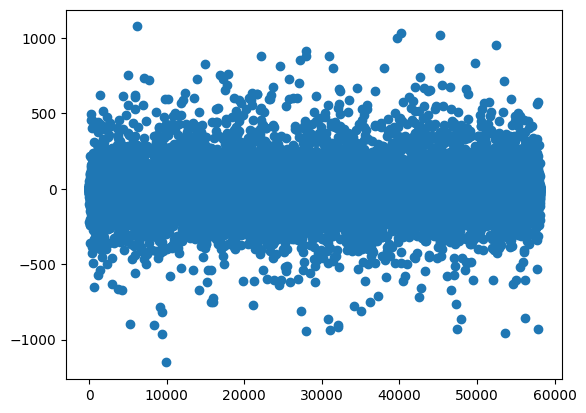

In [144]:
# plt.scatter(range(len(X_test)), y_test - np.e**model.predict(X_test))
plt.scatter(range(len(X_test)), y_test - np.e**model.predict(X_test))

In [147]:
np.mean(abs(y_test - model.predict(X_test))<50)

0.8410499139414802

In [150]:
from joblib import dump, load

In [152]:
dump(model, "distance_estimation_model.joblib")

['distance_estimation_model.joblib']

In [158]:
mdl1 = load("distance_estimation_model.joblib")
mdl1.predict(np.array([[0, 0, 0]]))

c:\Users\asing\anaconda3\envs\self-driving-car\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


array([629.35446234])